# Respiratory Sound Diagnosis Classifier

CNN-based classifier for predicting respiratory diagnoses (COPD, Pneumonia, URTI, etc.) from spectrograms.

## Sprints Overview

- **Sprint 1:** Scope definition, data loading, spectrogram inspection
- **Sprint 2:** Dataset creation, CNN baseline implementation, initial metrics
- **Sprint 3:** Patient-level aggregation, CNN refinement, comprehensive evaluation
- **Sprint 4:** Improvements in the model, inbalance treatment and refinement
- **Sprint 5:** Final evaluation

In [1]:
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import librosa
import librosa.display

# Configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Paths
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / 'processed_audio').exists() else cwd.parent
metadata_path = project_root / 'processed_audio' / 'metadata.csv'
spectrograms_dir = project_root / 'processed_audio' / 'spectrograms'
audio_dir = project_root / 'processed_audio' / 'audio'

print('Project root:', project_root)
print('Metadata path:', metadata_path)
print('Spectrograms dir:', spectrograms_dir)


Project root: /Users/guilhermekaidei/Desktop/Insper/AI_Medicine/Project
Metadata path: /Users/guilhermekaidei/Desktop/Insper/AI_Medicine/Project/processed_audio/metadata.csv
Spectrograms dir: /Users/guilhermekaidei/Desktop/Insper/AI_Medicine/Project/processed_audio/spectrograms


## Sprint 1: Scope & Data Exploration

### 1.1) Load and Inspect Metadata

In [2]:
if not metadata_path.exists():
    raise FileNotFoundError(f'Metadata file not found: {metadata_path}')

df = pd.read_csv(metadata_path)

print(f'Total samples: {len(df)}')
print(f'Total patients: {df["patient_id"].nunique()}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nDataframe shape: {df.shape}')
print(f'\nFirst rows:')
display(df.head())

print(f'\nData types:')
display(df.dtypes)

print(f'\nDiagnosis value counts:')
display(df['diagnosis'].value_counts())


Total samples: 6898
Total patients: 126

Columns: ['patient_id', 'original_file', 'cycle_index', 'spectrogram_path', 'start_time', 'end_time', 'duration', 'crackles', 'wheezes', 'diagnosis', 'split']

Dataframe shape: (6898, 11)

First rows:


,patient_id,original_file,cycle_index,spectrogram_path,start_time,end_time,duration,crackles,wheezes,diagnosis,split
0,101,101_1b1_Al_sc_Meditron,0,processed_audio/101/101_1b1_Al_sc_Meditron_cyc...,0.036,0.579,0.543,0,0,URTI,validation
1,101,101_1b1_Al_sc_Meditron,1,processed_audio/101/101_1b1_Al_sc_Meditron_cyc...,0.579,2.450,1.871,0,0,URTI,validation
2,101,101_1b1_Al_sc_Meditron,2,processed_audio/101/101_1b1_Al_sc_Meditron_cyc...,2.450,3.893,1.443,0,0,URTI,validation
3,101,101_1b1_Al_sc_Meditron,3,processed_audio/101/101_1b1_Al_sc_Meditron_cyc...,3.893,5.793,1.900,0,0,URTI,validation
4,101,101_1b1_Al_sc_Meditron,4,processed_audio/101/101_1b1_Al_sc_Meditron_cyc...,5.793,7.521,1.728,0,0,URTI,validation



Data types:


patient_id            int64
original_file           str
cycle_index           int64
spectrogram_path        str
start_time          float64
end_time            float64
duration            float64
crackles              int64
wheezes               int64
diagnosis               str
split                   str
dtype: object


Diagnosis value counts:


diagnosis
COPD              5746
Healthy            322
Pneumonia          285
URTI               243
Bronchiolitis      160
Bronchiectasis     104
LRTI                32
Asthma               6
Name: count, dtype: int64

### 1.2) Spectrogram Loading & Inspection

In [13]:
def load_spectrogram(filepath, target_shape=(128, 128)):
    """Load a spectrogram numpy file."""
    try:
        spec = np.load(filepath)
        # Ensure it matches target shape
        if spec.shape != target_shape:
            # Resize if needed
            from scipy import ndimage
            zoom_factors = (target_shape[0] / spec.shape[0], target_shape[1] / spec.shape[1])
            spec = ndimage.zoom(spec, zoom_factors, order=1)
        return spec
    except Exception as e:
        print(f'Error loading {filepath}: {e}')
        return None

def load_audio(filepath):
    """Load audio file with librosa."""
    try:
        y, sr = librosa.load(filepath, sr=22050)
        return y, sr
    except Exception as e:
        print(f'Error loading {filepath}: {e}')
        return None, None

# Check if spectrograms directory exists
if spectrograms_dir.exists():
    spec_files = list(spectrograms_dir.glob('*.npy'))
    print(f'Found {len(spec_files)} spectrogram files')
    
    # Try to load one for inspection
    if spec_files:
        test_spec = load_spectrogram(spec_files[0])
        if test_spec is not None:
            print(f'Spectrogram shape: {test_spec.shape}')
            print(f'Min: {test_spec.min():.2f}, Max: {test_spec.max():.2f}')
else:
    print(f'Spectrograms directory not found: {spectrograms_dir}')
    print('We will generate spectrograms from metadata and audio files')


Spectrograms directory not found: /Users/guilhermekaidei/Desktop/Insper/AI_Medicine/Project/processed_audio/spectrograms
We will generate spectrograms from metadata and audio files


### 1.3) Visual Exploration by Diagnosis Class

Diagnosis classes: <StringArray>
[          'URTI',        'Healthy',         'Asthma',           'COPD',
           'LRTI', 'Bronchiectasis',      'Pneumonia',  'Bronchiolitis']
Length: 8, dtype: str


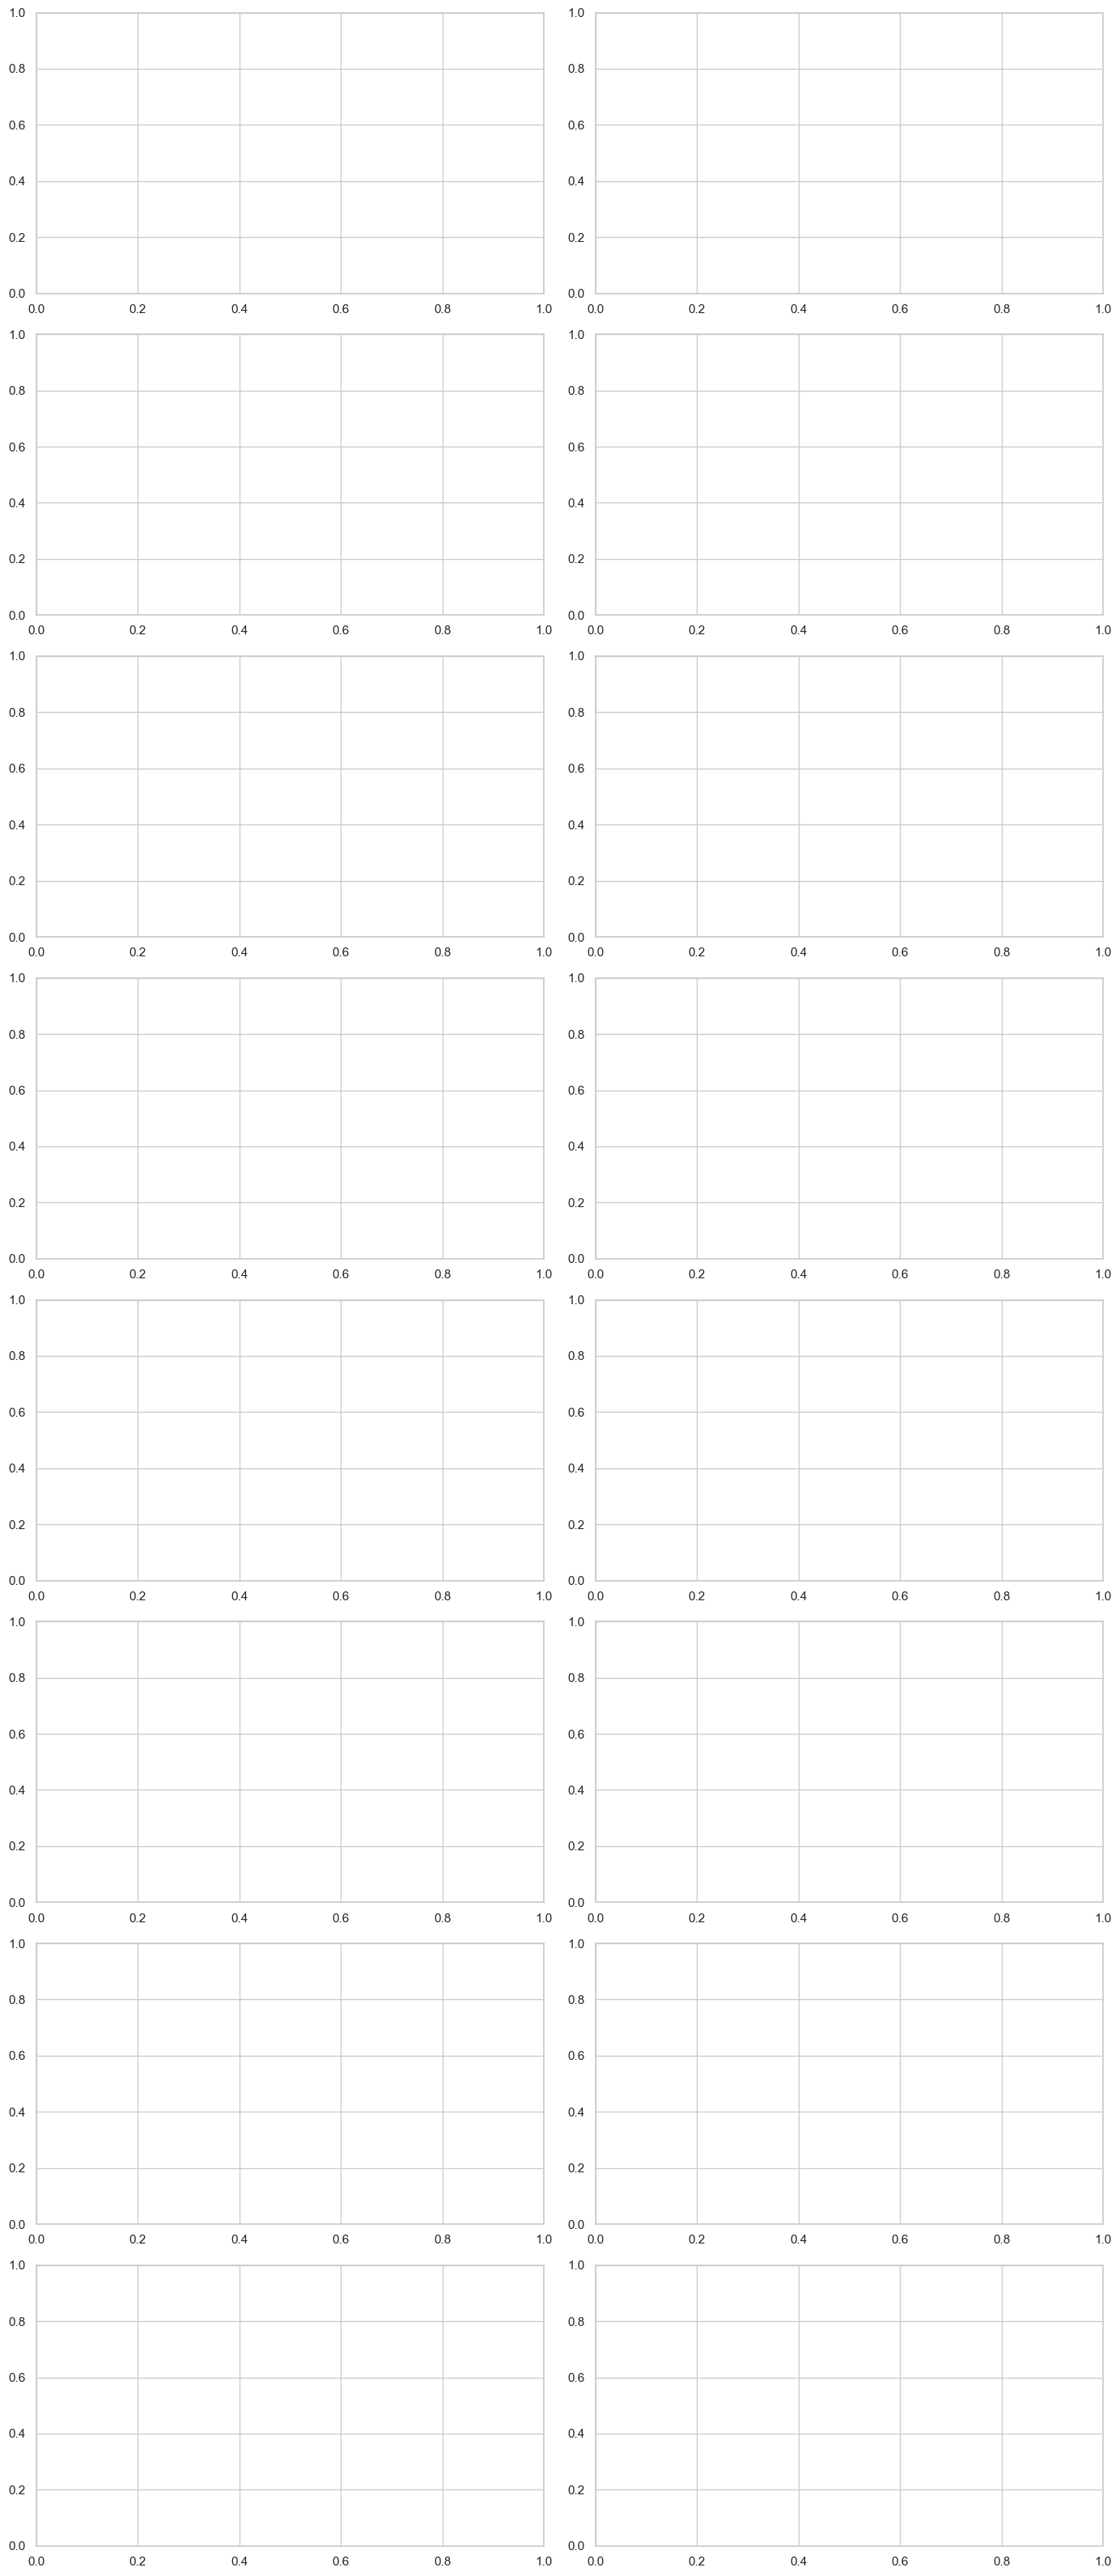

In [4]:
# Get samples from each diagnosis class
if 'diagnosis' in df.columns:
    diagnoses = df['diagnosis'].unique()
    print(f'Diagnosis classes: {diagnoses}')
    
    fig, axes = plt.subplots(len(diagnoses), 2, figsize=(14, 4*len(diagnoses)))
    if len(diagnoses) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, diagnosis in enumerate(diagnoses):
        # Get a sample for this diagnosis
        sample_row = df[df['diagnosis'] == diagnosis].iloc[0]
        
        # Try to load spectrogram
        if spectrograms_dir.exists():
            spec_path = spectrograms_dir / f"{sample_row['spectrogram_file']}"
            if spec_path.exists():
                spec = load_spectrogram(spec_path)
                if spec is not None:
                    im = axes[idx, 0].imshow(spec, aspect='auto', origin='lower', cmap='viridis')
                    axes[idx, 0].set_title(f'{diagnosis} - Spectrogram')
                    axes[idx, 0].set_ylabel('Frequency Bins')
                    axes[idx, 0].set_xlabel('Time Frames')
                    plt.colorbar(im, ax=axes[idx, 0])
        
        # Try to load and plot audio waveform
        if 'audio_file' in sample_row and pd.notna(sample_row['audio_file']):
            audio_path = audio_dir / sample_row['audio_file'] if audio_dir.exists() else None
            if audio_path and audio_path.exists():
                y, sr = load_audio(audio_path)
                if y is not None:
                    librosa.display.waveshow(y, sr=sr, ax=axes[idx, 1])
                    axes[idx, 1].set_title(f'{diagnosis} - Waveform')
                    axes[idx, 1].set_ylabel('Amplitude')
    
    plt.tight_layout()
    plt.show()
else:
    print('No diagnosis column found')


## Sprint 2: Dataset & Baseline CNN

### 2.1) Prepare Training Data

In [5]:
def load_spectrograms_from_directory(df, spec_dir, target_shape=(128, 128)):
    """Load all spectrograms from directory."""
    X = []
    y_diagnosis = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        spec_file = row.get('spectrogram_file')
        diagnosis = row.get('diagnosis')
        
        if pd.isna(spec_file) or pd.isna(diagnosis):
            continue
        
        spec_path = spec_dir / spec_file
        if not spec_path.exists():
            continue
        
        spec = load_spectrogram(spec_path, target_shape)
        if spec is not None:
            X.append(spec)
            y_diagnosis.append(diagnosis)
            valid_indices.append(idx)
    
    return np.array(X), np.array(y_diagnosis), valid_indices

# Load spectrograms if available
if spectrograms_dir.exists():
    print('Loading spectrograms...')
    X, y_diagnosis, valid_indices = load_spectrograms_from_directory(df, spectrograms_dir)
    
    print(f'Loaded {len(X)} spectrograms')
    print(f'Spectrogram shape: {X.shape}')
    print(f'Diagnosis distribution:')
    unique, counts = np.unique(y_diagnosis, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'  {u}: {c}')
    
    # Normalize spectrograms
    X = (X - X.mean()) / (X.std() + 1e-8)
    X = X[..., np.newaxis]  # Add channel dimension for CNN
    
    print(f'Normalized X shape: {X.shape}')
else:
    print('Spectrograms directory not found. Cannot load data.')
    X = None


Spectrograms directory not found. Cannot load data.


In [6]:
# Encode labels
if X is not None:
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_diagnosis)
    n_classes = len(label_encoder.classes_)
    
    print(f'Classes: {label_encoder.classes_}')
    print(f'Number of classes: {n_classes}')
    
    # Split data: train (60%), validation (20%), test (20%)
    # First split: 80% train+val, 20% test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
    )
    
    # Second split: 75% train (of temp), 25% val (of temp)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
    )
    
    print(f'\nData split:')
    print(f'  Train: {X_train.shape[0]} samples')
    print(f'  Val: {X_val.shape[0]} samples')
    print(f'  Test: {X_test.shape[0]} samples')


### 2.2) Build Baseline CNN Model

In [7]:
def build_cnn_model(input_shape, num_classes):
    """Build a CNN model for spectrogram classification."""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Flatten and Dense
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

if X is not None:
    # Build model
    input_shape = X_train.shape[1:]
    model = build_cnn_model(input_shape, n_classes)
    
    # Compile
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print('Model architecture:')
    model.summary()


### 2.3) Train Model

In [8]:
if X is not None:
    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
    
    # Train model
    print('Training model...')
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Model Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Model Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()


## Sprint 3: Aggregation & Refinement

### 3.1) Cycle-Level Predictions & Patient Aggregation

In [9]:
if X is not None:
    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f'Test Loss: {test_loss:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')
    
    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Classification report
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=ax
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Confusion Matrix - Test Set')
    plt.tight_layout()
    plt.show()


### 3.2) Comprehensive Evaluation Metrics

In [10]:
### 3.3) ROC Curves & Advanced Metrics

### 3.4) Save Model Artifacts

In [11]:
def predict_diagnosis(spectrogram_path, model, label_encoder, target_shape=(128, 128)):
    """Predict diagnosis from a spectrogram."""
    spec = load_spectrogram(spectrogram_path, target_shape)
    if spec is None:
        return None, None
    
    # Normalize
    spec = (spec - spec.mean()) / (spec.std() + 1e-8)
    spec = spec[np.newaxis, ..., np.newaxis]  # Add batch and channel dimensions
    
    # Predict
    probs = model.predict(spec, verbose=0)
    predicted_class = np.argmax(probs[0])
    confidence = probs[0][predicted_class]
    
    diagnosis = label_encoder.classes_[predicted_class]
    
    return diagnosis, confidence, probs[0]

if X is not None:
    # Test on a few samples from test set
    test_indices = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)
    
    fig, axes = plt.subplots(len(test_indices), 2, figsize=(14, 3*len(test_indices)))
    if len(test_indices) == 1:
        axes = axes.reshape(1, -1)
    
    for plot_idx, test_idx in enumerate(test_indices):
        # Show spectrogram
        spec = X_test[test_idx, :, :, 0]
        im = axes[plot_idx, 0].imshow(spec, aspect='auto', origin='lower', cmap='viridis')
        axes[plot_idx, 0].set_title('Test Sample Spectrogram')
        axes[plot_idx, 0].set_ylabel('Frequency Bins')
        axes[plot_idx, 0].set_xlabel('Time Frames')
        plt.colorbar(im, ax=axes[plot_idx, 0])
        
        # Show predictions
        true_label = label_encoder.classes_[y_test[test_idx]]
        pred_probs = y_pred_probs[test_idx]
        
        classes_list = list(label_encoder.classes_)
        colors = ['green' if label_encoder.transform([c])[0] == y_test[test_idx] else 'blue' 
                  for c in classes_list]
        
        axes[plot_idx, 1].barh(classes_list, pred_probs, color=colors, alpha=0.7)
        axes[plot_idx, 1].set_xlabel('Probability')
        axes[plot_idx, 1].set_title(f'True: {true_label}')
        axes[plot_idx, 1].set_xlim([0, 1])
        
        for i, v in enumerate(pred_probs):
            axes[plot_idx, 1].text(v + 0.01, i, f'{v:.2f}', va='center')
    
    plt.tight_layout()
    plt.show()


### 3.5) Sample Predictions & Visualization

In [12]:
if X is not None:
    import pickle
    
    # Save model
    model_path = project_root / 'models'
    model_path.mkdir(exist_ok=True)
    
    model_file = model_path / 'diagnosis_classifier.h5'
    model.save(model_file)
    print(f'Model saved to {model_file}')
    
    # Save encoder
    encoder_file = model_path / 'label_encoder.pkl'
    with open(encoder_file, 'wb') as f:
        pickle.dump(label_encoder, f)
    print(f'Label encoder saved to {encoder_file}')
    
    # Save training info
    info = {
        'classes': label_encoder.classes_.tolist(),
        'n_classes': n_classes,
        'test_accuracy': float(test_accuracy),
        'test_loss': float(test_loss),
        'input_shape': input_shape
    }
    
    info_file = model_path / 'model_info.txt'
    with open(info_file, 'w') as f:
        for key, value in info.items():
            f.write(f'{key}: {value}\n')
    print(f'Model info saved to {info_file}')
